**1. Generación o carga de datos**

* Crear datos simulados

In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Crear dataset de usuarios
data = pd.DataFrame({
    'user_id': range(1, 101),
    'compras': np.random.randint(0, 20, 100),
    'monto_total': np.random.randint(10, 500, 100),
    'dias_ultimo_login': np.random.randint(1, 60, 100)
})

data.head()

,user_id,compras,monto_total,dias_ultimo_login
0,1,6,108,49
1,2,19,181,58
2,3,14,369,52
3,4,10,223,12
4,5,7,484,39


**2. Limpieza de datos**

In [5]:
# Verificar nulos
print(data.isnull().sum())
data = data.drop_duplicates()

user_id              0
compras              0
monto_total          0
dias_ultimo_login    0
dtype: int64


**3. Transformación**

In [6]:
# Crear categoría de usuario según actividad
data['activo'] = data['dias_ultimo_login'].apply(lambda x: 1 if x < 30 else 0)

**4. Sistema de Puntos**

In [7]:
# 1 punto por cada $10 gastados
data['puntos'] = data['monto_total'] // 10

# Bonus por usuarios activos
data['puntos'] = data.apply(lambda row: row['puntos'] + 20 if row['activo'] == 1 else row['puntos'], axis=1)

data.head()

,user_id,compras,monto_total,dias_ultimo_login,activo,puntos
0,1,6,108,49,0,10
1,2,19,181,58,0,18
2,3,14,369,52,0,36
3,4,10,223,12,1,42
4,5,7,484,39,0,48


**5. Clasificación de usuarios**

In [8]:
def segmentar(puntos):
    if puntos > 200:
        return 'Premium'
    elif puntos > 100:
        return 'Frecuente'
    else:
        return 'Ocasional'

data['segmento'] = data['puntos'].apply(segmentar)

**6. Análisis simple**

In [9]:
print(data['segmento'].value_counts())
print("Promedio de puntos:", data['puntos'].mean())

segmento
Ocasional    100
Name: count, dtype: int64
Promedio de puntos: 34.33


**7. Detección de churn**

In [10]:
data['churn'] = data['dias_ultimo_login'].apply(lambda x: 1 if x > 45 else 0)

print("Usuarios en riesgo de churn:", data['churn'].sum())

Usuarios en riesgo de churn: 28


**8. Visualizaciones**

* Gráfica 1 - Segmentos de usuarios

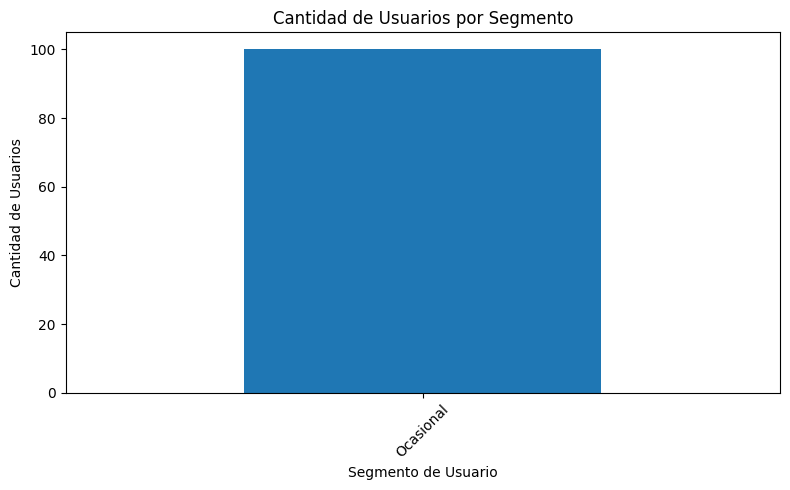

In [11]:
import matplotlib.pyplot as plt

# Verificar que el DataFrame 'data' y la columna 'segmento' existen
if 'data' in globals() and 'segmento' in data.columns:
    # Crear la gráfica de barras
    data['segmento'].value_counts().plot(kind='bar', figsize=(8, 5))

    # Añadir título y etiquetas a los ejes
    plt.title('Cantidad de Usuarios por Segmento')
    plt.xlabel('Segmento de Usuario')
    plt.ylabel('Cantidad de Usuarios')

    # Mejorar la visualización
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Mostrar la gráfica
    plt.show()
else:
    print("Error: El DataFrame 'data' o la columna 'segmento' no están definidos. Asegúrate de ejecutar las celdas anteriores.")

* Gráfica 2 - Distribución de Puntos

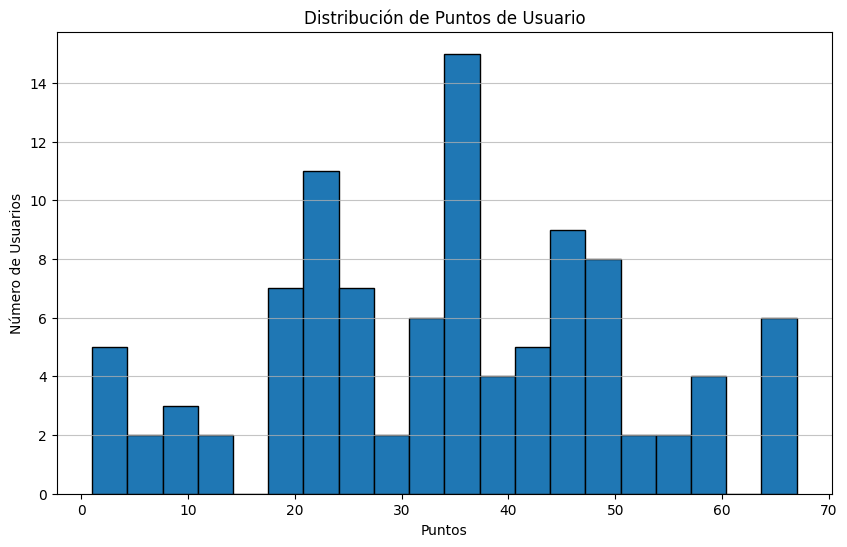

In [12]:
import matplotlib.pyplot as plt

# Verificar que el DataFrame 'data' y la columna 'puntos' existen
if 'data' in globals() and 'puntos' in data.columns:
    # Crear el histograma
    plt.figure(figsize=(10, 6))
    plt.hist(data['puntos'], bins=20, edgecolor='black')

    # Añadir título y etiquetas a los ejes
    plt.title('Distribución de Puntos de Usuario')
    plt.xlabel('Puntos')
    plt.ylabel('Número de Usuarios')

    # Mostrar la gráfica
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("Error: El DataFrame 'data' o la columna 'puntos' no están definidos. Asegúrate de ejecutar las celdas anteriores.")

* Gráfica 3 - Riesgo de Churn

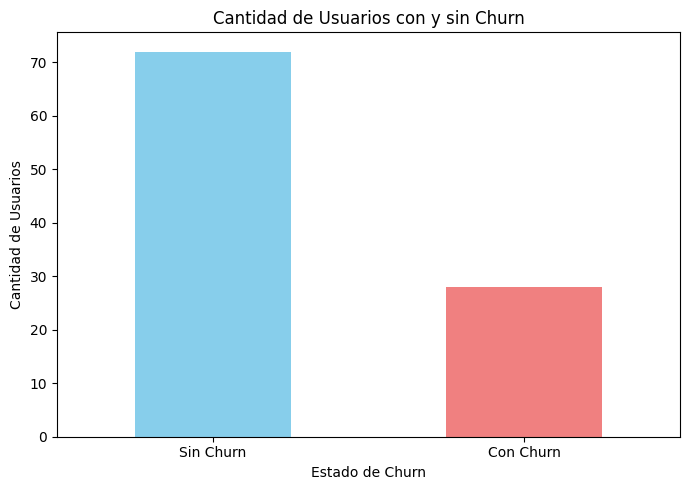

In [13]:
import matplotlib.pyplot as plt

# Verificar que el DataFrame 'data' y la columna 'churn' existen
if 'data' in globals() and 'churn' in data.columns:
    # Calcular la cantidad de usuarios con y sin churn
    churn_counts = data['churn'].value_counts()

    # Renombrar los índices para una mejor visualización en la gráfica
    churn_labels = {0: 'Sin Churn', 1: 'Con Churn'}
    churn_counts = churn_counts.rename(index=churn_labels)

    # Crear la gráfica de barras
    plt.figure(figsize=(7, 5))
    churn_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])

    # Añadir título y etiquetas a los ejes
    plt.title('Cantidad de Usuarios con y sin Churn')
    plt.xlabel('Estado de Churn')
    plt.ylabel('Cantidad de Usuarios')

    # Rotar las etiquetas del eje x si es necesario y ajustar diseño
    plt.xticks(rotation=0)
    plt.tight_layout()

    # Mostrar la gráfica
    plt.show()
else:
    print("Error: El DataFrame 'data' o la columna 'churn' no están definidos. Asegúrate de ejecutar las celdas anteriores.")

**9. Conclusión**

El sistema implementado permitió simular una arquitectura básica de recompensas inspirada en Amazon Prime. A través de procesos de limpieza, transformación y análisis de datos, fue posible identificar segmentos de usuarios, calcular puntos y detectar posibles clientes en riesgo de abandono. Además, las visualizaciones facilitaron el análisis del comportamiento general de los usuarios dentro del sistema.